# Global Annotation Comparison

Agreement metrics across all three annotation tasks:
- **Event Relation** — span event labels (binary) + sequencing / causality ratings (1–5)
- **Agency** — 6 Likert dimensions (1–5): focalization, emotion, cognition, motivation, change_of_state, conflict
- **Setting** — 4 Likert dimensions (1–5): concreteness, temporal_grounding, spatial_grounding, sensory

Metrics: exact match, within-1 (|diff| ≤ 1), MAE, Krippendorff's α, ICC(2,1).  
Rows with fewer than 3 shared instances show `—`.

In [8]:
import json
import csv
import numpy as np
import krippendorff
from IPython.display import display, HTML

## Configuration

In [9]:
BASE = '..'

TASKS = {
    'event_relation': {
        'label': 'Event Relation',
        'results_dir': f'{BASE}/event_relation_annotation_task/annotation_output/results',
        'annotators': ['adde1214', 'tejo9855'],
        'format': 'event_relation',
    },
    'agency': {
        'label': 'Agency',
        'results_dir': f'{BASE}/agency_annotation_task/agency_annotations/annotation_output/results',
        'annotators': ['tejo9855'],   # add second annotator username here when ready
        'format': 'likert',
        'dimensions': [
            'agency_focalization', 'agency_emotion', 'agency_cognition',
            'agency_motivation', 'agency_change_of_state', 'agency_conflict',
        ],
    },
    'setting': {
        'label': 'Setting',
        'results_dir': f'{BASE}/setting_annotation_task/annotation_output/results',
        'annotators': ['tejo9855', 'zeet'],   # add more annotators here when ready
        'format': 'likert',
        'dimensions': [
            'setting_concreteness', 'setting_temporal_grounding',
            'setting_spatial_grounding', 'setting_sensory',
        ],
    },
}

CSV_PATH = f'{BASE}/event_relation_annotation_task/data/dolma_combined_final_sample_700_with_llm_summary_safeid_with_spans.csv'
MIN_PAIRS = 3   # minimum shared instances required to report agreement metrics

## Load Data

In [10]:
csv.field_size_limit(10**7)
with open(CSV_PATH) as f:
    rows_in_order = list(csv.DictReader(f))
dataset_order = [r['safe_instance_id'] for r in rows_in_order]
print(f'Dataset: {len(dataset_order)} instances')

def parse_event_relation(val):
    inner = val[0][1]
    if not inner:
        return None
    parsed = json.loads(inner)
    return parsed[0] if parsed else None

def parse_likert(val):
    """Last entry per schema wins (Potato stores an edit log)."""
    result = {}
    for entry in val:
        result[entry[0]['schema']] = int(entry[0]['name'])
    return result

all_data = {}   # task_key -> annotator -> {inst_id -> parsed_annotation}

for task_key, cfg in TASKS.items():
    all_data[task_key] = {}
    parser = parse_event_relation if cfg['format'] == 'event_relation' else parse_likert
    for ann in cfg['annotators']:
        path = f"{cfg['results_dir']}/{ann}/user_state.json"
        try:
            with open(path) as f:
                state = json.load(f)
            all_data[task_key][ann] = {
                inst_id: parser(val)
                for inst_id, val in state['instance_id_to_label_to_value'].items()
            }
            print(f"  {cfg['label']} / {ann}: {len(all_data[task_key][ann])} instances")
        except FileNotFoundError:
            print(f"  {cfg['label']} / {ann}: file not found — skipping")
            all_data[task_key][ann] = {}

Dataset: 679 instances
  Event Relation / adde1214: 41 instances
  Event Relation / tejo9855: 51 instances
  Agency / tejo9855: 21 instances
  Setting / tejo9855: 21 instances
  Setting / zeet: 3 instances


## Metric Helpers

In [11]:
def exact_match(pairs):
    if not pairs: return None
    return sum(a == b for a, b in pairs) / len(pairs)

def within_one(pairs):
    if not pairs: return None
    return sum(abs(a - b) <= 1 for a, b in pairs) / len(pairs)

def mae(pairs):
    if not pairs: return None
    return float(np.mean([abs(a - b) for a, b in pairs]))

def alpha(pairs, binary=False):
    """Krippendorff's alpha. Nominal metric for binary, interval for ordinal."""
    if len(pairs) < 2: return None
    y1, y2 = zip(*pairs)
    if len(set(y1) | set(y2)) < 2: return None
    level = 'nominal' if binary else 'interval'
    data = np.array([list(y1), list(y2)], dtype=float)
    try:
        return krippendorff.alpha(data, level_of_measurement=level)
    except Exception:
        return None

def icc_two_way(pairs):
    if len(pairs) < 2: return None
    data = np.array(pairs, dtype=float)
    n, k = data.shape
    grand_mean    = data.mean()
    subject_means = data.mean(axis=1)
    rater_means   = data.mean(axis=0)
    SS_subjects = k * ((subject_means - grand_mean) ** 2).sum()
    SS_raters   = n * ((rater_means   - grand_mean) ** 2).sum()
    SS_total    = ((data - grand_mean) ** 2).sum()
    SS_error    = SS_total - SS_subjects - SS_raters
    MS_subjects = SS_subjects / (n - 1)
    MS_raters   = SS_raters   / (k - 1)
    MS_error    = SS_error    / ((n - 1) * (k - 1))
    denom = MS_subjects + (k - 1) * MS_error + k * (MS_raters - MS_error) / n
    if denom == 0: return None
    return (MS_subjects - MS_error) / denom

def fmt(v, pct=False):
    if v is None: return '<span style="color:#bbb">—</span>'
    return f'{v*100:.1f}%' if pct else f'{v:.3f}'

def compute_row(pairs, binary=False):
    n = len(pairs)
    if n < MIN_PAIRS:
        return {'n': n, 'em': None, 'w1': None, 'mae': None, 'alpha': None, 'icc': None}
    return {
        'n':     n,
        'em':    exact_match(pairs),
        'w1':    None if binary else within_one(pairs),
        'mae':   None if binary else mae(pairs),
        'alpha': alpha(pairs, binary=binary),
        'icc':   None if binary else icc_two_way(pairs),
    }

## Global Agreement Summary

One row per annotated dimension. Rows with fewer than 3 shared instances show `—`.

In [12]:
table_rows = []

# ── Event Relation ────────────────────────────────────────────────────────────
er1 = all_data['event_relation'].get('adde1214', {})
er2 = all_data['event_relation'].get('tejo9855', {})
shared_er = set(er1) & set(er2)

sp1_ev, sp2_ev, seq_pairs, caus_pairs = [], [], [], []
for inst_id in dataset_order:
    if inst_id not in shared_er: continue
    a1, a2 = er1.get(inst_id), er2.get(inst_id)
    if a1 is None or a2 is None: continue
    sp1_ev.append((int(bool(a1.get('span1_is_event'))), int(bool(a2.get('span1_is_event')))))
    sp2_ev.append((int(bool(a1.get('span2_is_event'))), int(bool(a2.get('span2_is_event')))))
    if a1.get('span1_is_event') and a1.get('span2_is_event') and \
       a2.get('span1_is_event') and a2.get('span2_is_event'):
        s1, s2 = a1.get('sequencing_rating'), a2.get('sequencing_rating')
        c1, c2 = a1.get('causality_rating'),  a2.get('causality_rating')
        if s1 is not None and s2 is not None: seq_pairs.append((int(s1), int(s2)))
        if c1 is not None and c2 is not None: caus_pairs.append((int(c1), int(c2)))

for label, pairs, binary in [
    ('Span 1 is event',  sp1_ev,     True),
    ('Span 2 is event',  sp2_ev,     True),
    ('Sequencing (1-5)', seq_pairs,  False),
    ('Causality (1-5)',  caus_pairs, False),
]:
    row = compute_row(pairs, binary=binary)
    row['task'] = 'Event Relation'
    row['dim']  = label
    row['ann_pair'] = 'adde1214 / tejo9855'
    table_rows.append(row)

# ── Agency ────────────────────────────────────────────────────────────────────
ag_anns = [a for a in TASKS['agency']['annotators'] if all_data['agency'].get(a)]
if len(ag_anns) >= 2:
    ag1k, ag2k = ag_anns[0], ag_anns[1]
    shared_ag = set(all_data['agency'][ag1k]) & set(all_data['agency'][ag2k])
    ann_pair_ag = f'{ag1k} / {ag2k}'
else:
    shared_ag = set()
    ann_pair_ag = (ag_anns[0] + ' only') if ag_anns else 'no data'

for dim in TASKS['agency']['dimensions']:
    pairs = []
    if len(ag_anns) >= 2:
        for inst_id in dataset_order:
            if inst_id not in shared_ag: continue
            v1 = all_data['agency'][ag_anns[0]].get(inst_id, {}).get(dim)
            v2 = all_data['agency'][ag_anns[1]].get(inst_id, {}).get(dim)
            if v1 is not None and v2 is not None:
                pairs.append((v1, v2))
    row = compute_row(pairs)
    row['task'] = 'Agency'
    row['dim']  = dim.replace('agency_', '').replace('_', ' ').title()
    row['ann_pair'] = ann_pair_ag
    table_rows.append(row)

# ── Setting ───────────────────────────────────────────────────────────────────
st_anns = [a for a in TASKS['setting']['annotators'] if all_data['setting'].get(a)]
if len(st_anns) >= 2:
    st1k, st2k = st_anns[0], st_anns[1]
    shared_st = set(all_data['setting'][st1k]) & set(all_data['setting'][st2k])
    ann_pair_st = f'{st1k} / {st2k}'
else:
    shared_st = set()
    ann_pair_st = (st_anns[0] + ' only') if st_anns else 'no data'

for dim in TASKS['setting']['dimensions']:
    pairs = []
    if len(st_anns) >= 2:
        for inst_id in dataset_order:
            if inst_id not in shared_st: continue
            v1 = all_data['setting'][st_anns[0]].get(inst_id, {}).get(dim)
            v2 = all_data['setting'][st_anns[1]].get(inst_id, {}).get(dim)
            if v1 is not None and v2 is not None:
                pairs.append((v1, v2))
    row = compute_row(pairs)
    row['task'] = 'Setting'
    row['dim']  = dim.replace('setting_', '').replace('_', ' ').title()
    row['ann_pair'] = ann_pair_st
    table_rows.append(row)

# ── Render ────────────────────────────────────────────────────────────────────
TASK_COLORS = {
    'Event Relation': '#e8f4fd',
    'Agency':         '#fdf3e8',
    'Setting':        '#edf8ee',
}

header = (
    '<tr style="background:#f0f0f0">'
    '<th style="padding:6px 12px;text-align:left">Task</th>'
    '<th style="padding:6px 12px;text-align:left">Dimension</th>'
    '<th style="padding:6px 12px">N</th>'
    '<th style="padding:6px 12px">Exact match</th>'
    '<th style="padding:6px 12px">Within 1</th>'
    '<th style="padding:6px 12px">MAE</th>'
    '<th style="padding:6px 12px">Krippendorff\'s α</th>'
    '<th style="padding:6px 12px">ICC(2,1)</th>'
    '<th style="padding:6px 12px;text-align:left;font-size:0.82em">Annotators</th>'
    '</tr>'
)

rows_html = ''
prev_task = None
for row in table_rows:
    bg = TASK_COLORS.get(row['task'], '#fff')
    if row['task'] != prev_task:
        task_cell = f'<td style="padding:6px 12px;background:{bg};font-weight:bold">{row["task"]}</td>'
    else:
        task_cell = f'<td style="padding:6px 12px;background:{bg}"></td>'
    prev_task = row['task']
    rows_html += (
        f'<tr style="border-top:1px solid #eee">'
        f'{task_cell}'
        f'<td style="padding:6px 12px">{row["dim"]}</td>'
        f'<td style="padding:6px 12px;text-align:center">{row["n"]}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["em"], pct=True)}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["w1"], pct=True)}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["mae"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["alpha"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["icc"])}</td>'
        f'<td style="padding:6px 12px;font-size:0.82em;color:#666">{row["ann_pair"]}</td>'
        f'</tr>'
    )

notes = (
    '<p style="color:#777;font-size:0.8em;margin-top:10px;line-height:1.6">'
    '<b>Within 1</b>: fraction of pairs differing by at most 1 point.<br>'
    '<b>MAE</b>: mean absolute error — average point difference between annotators.<br>'
    '<b>Krippendorff\'s α</b>: nominal metric for binary labels; interval metric for ordinal scales.<br>'
    '<b>ICC(2,1)</b>: two-way random effects; credits agreement even when one annotator rates systematically higher/lower.<br>'
    f'Rows with N &lt; {MIN_PAIRS} show — (insufficient shared instances).'
    '</p>'
)

display(HTML(
    '<div style="font-family:sans-serif">'
    '<table style="border-collapse:collapse;font-size:0.92em">'
    f'<thead>{header}</thead><tbody>{rows_html}</tbody>'
    '</table>'
    + notes +
    '</div>'
))

Task,Dimension,N,Exact match,Within 1,MAE,Krippendorff's α,"ICC(2,1)",Annotators
Event Relation,Span 1 is event,41,75.6%,—,—,0.297,—,adde1214 / tejo9855
,Span 2 is event,41,73.2%,—,—,0.113,—,adde1214 / tejo9855
,Sequencing (1-5),19,31.6%,78.9%,0.895,0.009,-0.009,adde1214 / tejo9855
,Causality (1-5),19,26.3%,52.6%,1.421,0.175,0.297,adde1214 / tejo9855
Agency,Focalization,0,—,—,—,—,—,tejo9855 only
,Emotion,0,—,—,—,—,—,tejo9855 only
,Cognition,0,—,—,—,—,—,tejo9855 only
,Motivation,0,—,—,—,—,—,tejo9855 only
,Change Of State,0,—,—,—,—,—,tejo9855 only
,Conflict,0,—,—,—,—,—,tejo9855 only


## Single-Annotator Distributions (Agency & Setting)

Rating distributions for each dimension. Useful context for calibration even before a second annotator finishes.

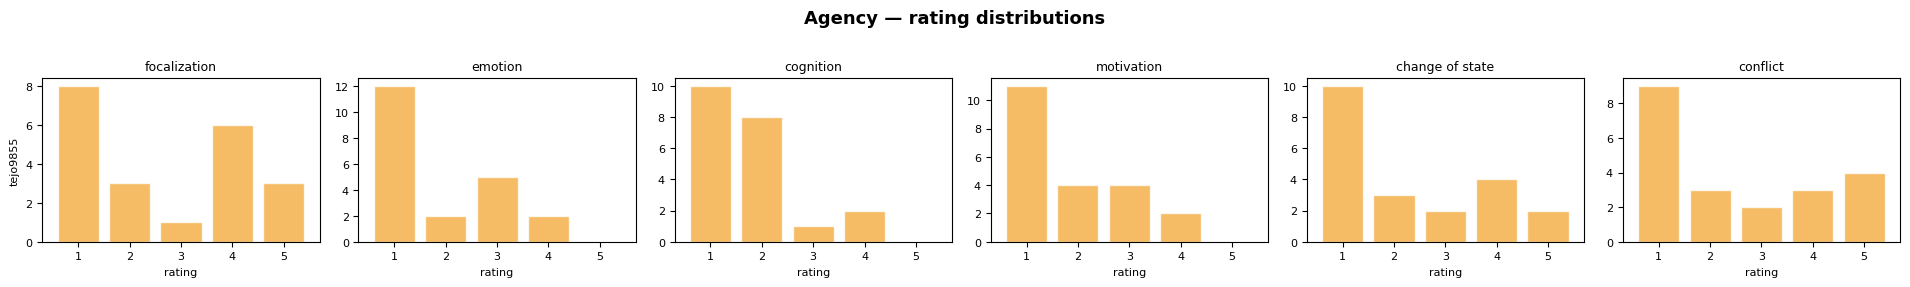

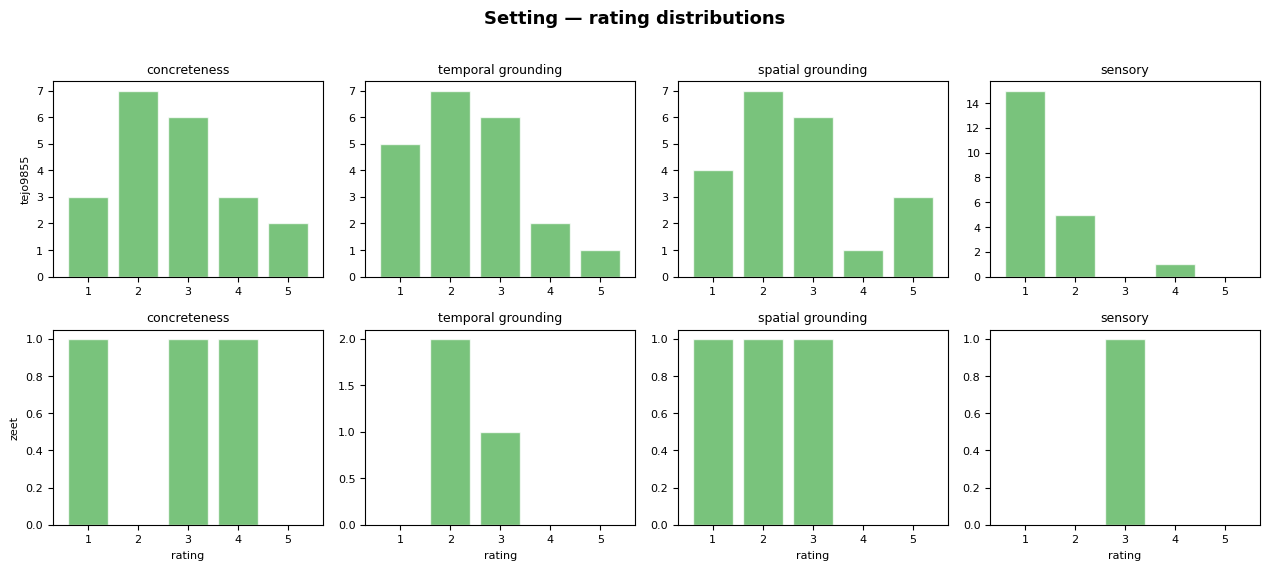

In [6]:
import matplotlib.pyplot as plt

TASK_PLOT_COLOR = {
    'agency':  '#f4a432',
    'setting': '#4caf50',
}

for task_key, cfg in TASKS.items():
    if cfg['format'] != 'likert':
        continue
    dims = cfg['dimensions']
    annotators = [a for a in cfg['annotators'] if all_data[task_key].get(a)]
    if not annotators:
        continue

    n_dims = len(dims)
    n_anns = len(annotators)
    fig, axes = plt.subplots(n_anns, n_dims, figsize=(3.2 * n_dims, 2.8 * n_anns),
                             sharey=False, squeeze=False)
    fig.suptitle(f'{cfg["label"]} — rating distributions', fontsize=13, fontweight='bold', y=1.01)

    color = TASK_PLOT_COLOR[task_key]
    for ai, ann in enumerate(annotators):
        ann_data = all_data[task_key][ann]
        for di, dim in enumerate(dims):
            ax = axes[ai][di]
            vals = [
                ann_data[inst].get(dim)
                for inst in ann_data
                if ann_data[inst] is not None and ann_data[inst].get(dim) is not None
            ]
            counts = [vals.count(v) for v in range(1, 6)]
            ax.bar(range(1, 6), counts, color=color, alpha=0.75, edgecolor='white')
            ax.set_xticks(range(1, 6))
            ax.set_xlim(0.3, 5.7)
            short = dim.split('_', 1)[1].replace('_', ' ') if '_' in dim else dim
            ax.set_title(short, fontsize=9)
            if di == 0:
                ax.set_ylabel(ann, fontsize=8)
            if ai == n_anns - 1:
                ax.set_xlabel('rating', fontsize=8)
            ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

## Event Relation — Per-Instance Detail

In [7]:
ANN1, ANN2 = 'adde1214', 'tejo9855'
er1 = all_data['event_relation'].get(ANN1, {})
er2 = all_data['event_relation'].get(ANN2, {})
shared_er = set(er1) & set(er2)

SPAN1_COLOR = '#4e9af1'
SPAN2_COLOR = '#f4a432'

detail_rows = []
for inst_id in dataset_order:
    if inst_id not in shared_er: continue
    a1, a2 = er1.get(inst_id), er2.get(inst_id)
    if a1 is None or a2 is None: continue

    sp1_agree = bool(a1.get('span1_is_event')) == bool(a2.get('span1_is_event'))
    sp2_agree = bool(a1.get('span2_is_event')) == bool(a2.get('span2_is_event'))

    def ev(ann, key): return 'Y' if ann.get(key) else 'N'
    def rat(ann, key): v = ann.get(key); return str(v) if v is not None else '-'

    seq1, seq2 = a1.get('sequencing_rating'), a2.get('sequencing_rating')
    cau1, cau2 = a1.get('causality_rating'),  a2.get('causality_rating')
    seq_str  = f'{seq1} / {seq2}' if seq1 is not None and seq2 is not None else '-'
    caus_str = f'{cau1} / {cau2}' if cau1 is not None and cau2 is not None else '-'

    green = 'background:#d4edda'
    detail_rows.append(
        f'<tr style="border-top:1px solid #eee">'
        f'<td style="padding:4px 10px;font-size:0.8em;color:#888">{inst_id}</td>'
        f'<td style="padding:4px 10px;text-align:center;{green if sp1_agree else ""}">'
            f'{ev(a1,"span1_is_event")} / {ev(a2,"span1_is_event")}</td>'
        f'<td style="padding:4px 10px;text-align:center;{green if sp2_agree else ""}">'
            f'{ev(a1,"span2_is_event")} / {ev(a2,"span2_is_event")}</td>'
        f'<td style="padding:4px 10px;text-align:center">{seq_str}</td>'
        f'<td style="padding:4px 10px;text-align:center">{caus_str}</td>'
        f'</tr>'
    )

detail_header = (
    '<tr style="background:#f0f0f0">'
    '<th style="padding:4px 10px;text-align:left">Instance</th>'
    f'<th style="padding:4px 10px;color:{SPAN1_COLOR}">Span 1 event ({ANN1} / {ANN2})</th>'
    f'<th style="padding:4px 10px;color:{SPAN2_COLOR}">Span 2 event ({ANN1} / {ANN2})</th>'
    '<th style="padding:4px 10px">Sequencing</th>'
    '<th style="padding:4px 10px">Causality</th>'
    '</tr>'
)

display(HTML(
    f'<div style="font-family:sans-serif">'
    f'<b>{ANN1}</b> vs <b>{ANN2}</b> — {len(detail_rows)} shared instances'
    f'<table style="border-collapse:collapse;font-size:0.9em;margin-top:8px">'
    f'<thead>{detail_header}</thead>'
    f'<tbody>{"".join(detail_rows)}</tbody>'
    '</table></div>'
))

Instance,Span 1 event (adde1214 / tejo9855),Span 2 event (adde1214 / tejo9855),Sequencing,Causality
inst_5267439fd5e6fa9c_0,Y / Y,Y / Y,5 / 5,4 / 4
inst_cb7b7cc8610afc27_1,Y / Y,Y / Y,3 / 4,4 / 2
inst_857ae18359aab76d_2,Y / Y,Y / Y,5 / 3,4 / 2
inst_c69d2c3bae55b7bc_3,Y / Y,Y / Y,4 / 5,1 / 2
inst_289b4547308edda7_4,Y / N,Y / N,-,-
inst_296e1f787f2f9d9a_5,Y / Y,Y / Y,5 / 4,4 / 3
inst_038aa920c8392d34_6,Y / Y,Y / N,-,-
inst_914f0e14c64e6c76_7,Y / Y,Y / Y,-,-
inst_519a328dd05e63db_8,Y / N,Y / Y,-,-
inst_24c673570e4ee7d9_9,Y / N,Y / Y,-,-
